# Clase de Redes Neuronales Convolucionales (CNN)

## Parte 4: YOLO — Detección de Objetos en Tiempo Real

**Objetivos de esta sección:**

1. Entender la diferencia entre **clasificación** y **detección** de objetos.
2. Conocer la **arquitectura de YOLOv1** y su revolución en detección en tiempo real.
3. Analizar la **función de pérdida** multi-componente de YOLO.
4. Realizar una **demostración práctica** con YOLO preentrenado (transfer learning) en Colab.
5. Comparar LeNet-5 (clasificación) vs YOLO (detección) y reflexionar sobre cuándo usar cada uno.

---

## 1. Clasificación vs Detección

### 1.1 La diferencia fundamental

| Tarea | Entrada | Salida | Ejemplo |
|-------|---------|--------|---------|
| **Clasificación** (LeNet-5) | Imagen | Una etiqueta | "Es un dígito 7" |
| **Detección** (YOLO) | Imagen | Múltiples cajas + etiquetas | "Perro en (x1,y1,w1,h1), gato en (x2,y2,w2,h2)" |

### 1.2 ¿Por qué es más difícil la detección?

1. **Múltiples objetos:** No sabemos cuántos objetos hay en la imagen.
2. **Localización:** Debemos predecir coordenadas exactas de cada objeto.
3. **Clasificación simultánea:** Cada objeto detectado debe clasificarse.
4. **Objetos superpuestos:** Los objetos pueden solaparse entre sí.

### 1.3 Enfoques previos a YOLO

- **R-CNN (2014):** Proponía ~2000 regiones candidatas, clasificaba cada una. Muy lento (~47s por imagen).
- **Fast R-CNN (2015):** Más rápido pero aún ~2s por imagen.
- **Faster R-CNN (2015):** Introduce RPN (Region Proposal Network). ~0.2s por imagen.

**Problema:** Todos estos métodos procesan la imagen en múltiples pasos. No son verdaderamente en tiempo real.

---

## 2. YOLO: You Only Look Once (Redmon et al., 2016)

### 2.1 La idea revolucionaria

YOLO reformula la detección como un **único problema de regresión**:

> Dada una imagen, predecir directamente todas las cajas y etiquetas en **un solo forward pass**.

**Consecuencias:**
- **45 FPS** en GPU (vs 0.02 FPS de R-CNN).
- **End-to-end:** se entrena directamente de imagen a detecciones.
- **Global:** ve toda la imagen a la vez (menos falsos positivos en fondos).

### 2.2 El truco de la cuadrícula (grid)

YOLO divide la imagen en una **cuadrícula $S \times S$** (ej. $7 \times 7$):

- Cada celda es responsable de detectar objetos cuyo **centro** cae en ella.
- Cada celda predice **$B$ bounding boxes** (ej. $B=2$).
- Cada bounding box tiene **5 valores:** $(x, y, w, h, \text{confianza})$.
- Cada celda predice **$C$ probabilidades de clase** (compartidas entre sus $B$ boxes).

### 2.3 Tensor de salida

Para $S=7$, $B=2$, $C=20$ (Pascal VOC):

$$\text{Salida} = S \times S \times (B \times 5 + C) = 7 \times 7 \times (2 \times 5 + 20) = 7 \times 7 \times 30$$

**Desglose de los 30 valores por celda:**
- 2 bounding boxes × 5 valores = 10
- 20 probabilidades de clase = 20
- **Total: 30**

### 2.4 Confianza

$$\text{Confianza} = P(\text{Objeto}) \times \text{IoU}_{\text{pred}}^{\text{truth}}$$

Donde **IoU** (Intersection over Union):

$$\text{IoU} = \frac{\text{Área de intersección}}{\text{Área de unión}}$$

- Si no hay objeto: confianza = 0.
- Si hay objeto: confianza = IoU entre caja predicha y real.

---

## 3. Arquitectura de YOLOv1

### 3.1 Estructura general

- **24 capas convolucionales** (inspiradas en GoogLeNet).
- **2 capas fully connected** al final.
- Alterna convoluciones $1\times1$ (reducción de canales) y $3\times3$.
- **Activación Leaky ReLU** (no ReLU estándar).

### 3.2 Diagrama ASCII

```
Entrada: 448×448×3
    ↓
[Conv 7×7, 64, stride 2] → 224×224×64
    ↓
[MaxPool 2×2] → 112×112×64
    ↓
[Conv 3×3, 192] → 112×112×192
    ↓
[MaxPool 2×2] → 56×56×192
    ↓
[Conv 1×1, 128] → 56×56×128
[Conv 3×3, 256] → 56×56×256
[Conv 1×1, 256] → 56×56×256
[Conv 3×3, 512] → 56×56×512
    ↓
[MaxPool 2×2] → 28×28×512
    ↓
... (4 bloques de Conv 1×1 + 3×3) ...
    ↓
[Conv 3×3, 1024] → 7×7×1024
    ↓
[Conv 3×3, 1024] → 7×7×1024
    ↓
[FC 4096] → 4096
[FC 4096] → 4096
    ↓
Salida: 7×7×30 (tensor de detecciones)
```

### 3.3 Dimensiones clave

| Parámetro | Valor |
|-----------|-------|
| Entrada | $448 \times 448 \times 3$ |
| Grid | $7 \times 7$ |
| Boxes por celda | 2 |
| Clases | 20 (Pascal VOC) |
| Salida | $7 \times 7 \times 30$ |
| Parámetros | ~millones |

---

## 4. Función de Pérdida de YOLO

### 4.1 Suma de errores cuadráticos con pesos

YOLO usa una **suma ponderada de errores cuadráticos** (SSE) con 5 componentes [citation:3][citation:17]:

$$\mathcal{L} = \underbrace{\lambda_{\text{coord}} \sum_{i=0}^{S^2} \sum_{j=0}^{B} \mathbb{1}_{ij}^{\text{obj}} \left[(x_i - \hat{x}_i)^2 + (y_i - \hat{y}_i)^2\right]}_{\text{Error de localización centro}}$$

$$+ \underbrace{\lambda_{\text{coord}} \sum_{i=0}^{S^2} \sum_{j=0}^{B} \mathbb{1}_{ij}^{\text{obj}} \left[(\sqrt{w_i} - \sqrt{\hat{w}_i})^2 + (\sqrt{h_i} - \sqrt{\hat{h}_i})^2\right]}_{\text{Error de tamaño (con raíz cuadrada)}}$$

$$+ \underbrace{\sum_{i=0}^{S^2} \sum_{j=0}^{B} \mathbb{1}_{ij}^{\text{obj}} (C_i - \hat{C}_i)^2}_{\text{Confianza con objeto}}$$

$$+ \underbrace{\lambda_{\text{noobj}} \sum_{i=0}^{S^2} \sum_{j=0}^{B} \mathbb{1}_{ij}^{\text{noobj}} (C_i - \hat{C}_i)^2}_{\text{Confianza sin objeto}}$$

$$+ \underbrace{\sum_{i=0}^{S^2} \mathbb{1}_i^{\text{obj}} \sum_{c \in \text{clases}} (p_i(c) - \hat{p}_i(c))^2}_{\text{Error de clasificación}}$$

### 4.2 Interpretación de los pesos

- **$\lambda_{\text{coord}} = 5$:** Se enfatiza la localización (coordenadas).
- **$\lambda_{\text{noobj}} = 0.5$:** Se reduce el peso de las celdas sin objeto (que son la mayoría).
- **$\sqrt{w}, \sqrt{h}$:** La raíz cuadrada penaliza menos los errores en cajas grandes y más en cajas pequeñas [citation:17].

### 4.3 Indicadores

- $\mathbb{1}_i^{\text{obj}}$: 1 si la celda $i$ contiene un objeto.
- $\mathbb{1}_{ij}^{\text{obj}}$: 1 si el box $j$ de la celda $i$ es responsable del objeto.
- $\mathbb{1}_{ij}^{\text{noobj}}$: 1 si el box $j$ de la celda $i$ NO contiene objeto.

---

## 5. Limitaciones de YOLOv1

### 5.1 Problemas conocidos

1. **Objetos pequeños:** La cuadrícula $7\times7$ es muy gruesa para objetos pequeños [citation:2].
2. **Objetos agrupados:** Si varios objetos caen en la misma celda, solo puede detectar $B=2$.
3. **Generalización a formatos nuevos:** Funciona peor en imágenes con aspect ratios no vistos.
4. **Localización imprecisa:** Los errores de localización son mayores que en métodos de dos etapas.

### 5.2 Evolución posterior

- **YOLOv2 (2017):** Anchor boxes, batch normalization, mejor resolución.
- **YOLOv3 (2018):** Multi-scale predictions (3 escalas).
- **YOLOv5/v8/v11 (2020+):** Mejoras arquitectónicas, mejor velocidad/precisión [citation:5].

---

## 6. Demostración Práctica: YOLO Preentrenado

### 6.1 ¿Por qué no entrenamos YOLO desde cero?

Entrenar YOLO desde cero requiere:

- **Dataset Pascal VOC:** ~10 GB.
- **135 épocas** en GPU potente [citation:15].
- **Días de entrenamiento.**

**Alternativa:** Usar **transfer learning** con un modelo YOLO preentrenado en COCO (80 clases, 330k imágenes) [citation:19].

### 6.2 El paquete Ultralytics

`ultralytics` es la librería más popular para usar YOLO en Python. Proporciona modelos preentrenados de YOLOv5, v8, v11, etc.

In [1]:
# ============ CELDA 1: Instalar Ultralytics ============
!pip install ultralytics --quiet

import torch
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.5.1+cu121
CUDA disponible: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
# ============ CELDA 2: Cargar YOLO preentrenado ============
from ultralytics import YOLO

# Cargar YOLOv8 nano (el más ligero, ideal para demos)
model = YOLO('yolov8n.pt')

print("Modelo YOLOv8n cargado.")
print(f"Clases: {len(model.names)} (COCO dataset)")
print(f"Ejemplos de clases: {list(model.names.values())[:10]}")

Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\yoda\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Modelo YOLOv8n cargado.
Clases: 80 (COCO dataset)
Ejemplos de clases: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


Imagen cargada: (810, 1080)


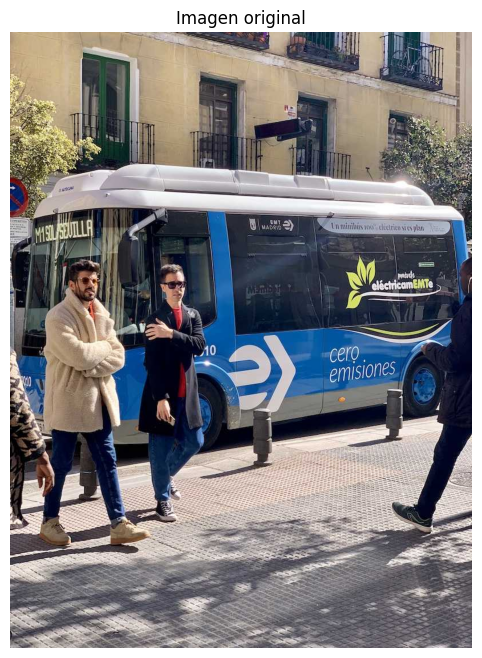

In [3]:
# ============ CELDA 3: Descargar una imagen de prueba ============
import urllib.request
import matplotlib.pyplot as plt
from PIL import Image

# Imagen clásica de YOLO: personas y perro
url = 'https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg'
urllib.request.urlretrieve(url, 'bus.jpg')

img = Image.open('bus.jpg')
print(f"Imagen cargada: {img.size}")

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title('Imagen original')
plt.show()

In [4]:
# ============ CELDA 4: Realizar detección ============
results = model('bus.jpg')

# Mostrar resultados
result = results[0]
print(f"Objetos detectados: {len(result.boxes)}")
print(f"Clases: {result.names}")

# Extraer información
for box in result.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print(f"  {result.names[cls_id]}: confianza={conf:.2f}, bbox={[round(x) for x in xyxy]}")


image 1/1 d:\ArchivosHDD\GitHub\cursoIA2026\Semana_08\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 15.1ms
Speed: 78.7ms preprocess, 15.1ms inference, 21.5ms postprocess per image at shape (1, 3, 640, 480)
Objetos detectados: 6
Clases: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 5

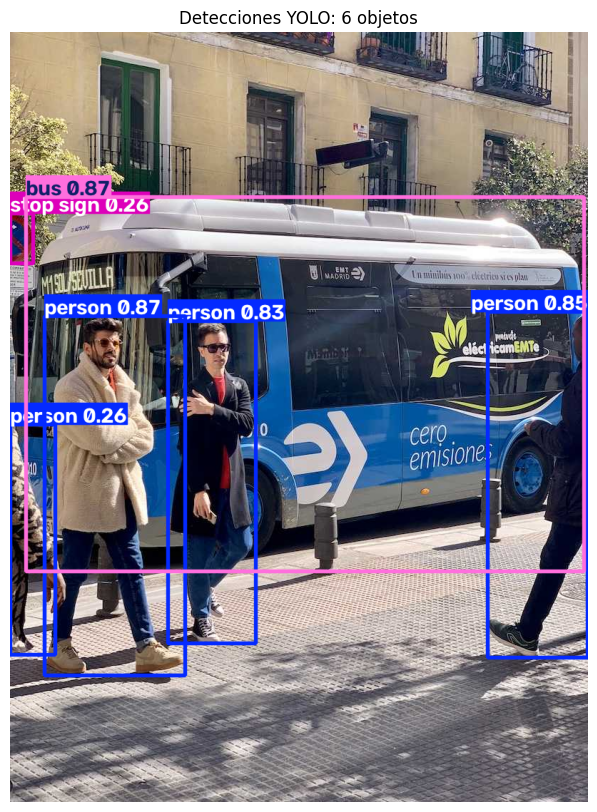


💡 Nota: YOLO detectó los objetos en un solo forward pass.
   El modelo está preentrenado en COCO (80 clases).


In [5]:
# ============ CELDA 5: Visualizar detecciones ============
# Renderizar imagen con bounding boxes
annotated_img = result.plot()

plt.figure(figsize=(12, 10))
plt.imshow(annotated_img[:, :, ::-1])  # BGR -> RGB
plt.axis('off')
plt.title(f'Detecciones YOLO: {len(result.boxes)} objetos')
plt.show()

print("\n💡 Nota: YOLO detectó los objetos en un solo forward pass.")
print("   El modelo está preentrenado en COCO (80 clases).")


image 1/1 d:\ArchivosHDD\GitHub\cursoIA2026\Semana_08\zidane.jpg: 384x640 2 persons, 1 tie, 81.6ms
Speed: 1.0ms preprocess, 81.6ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


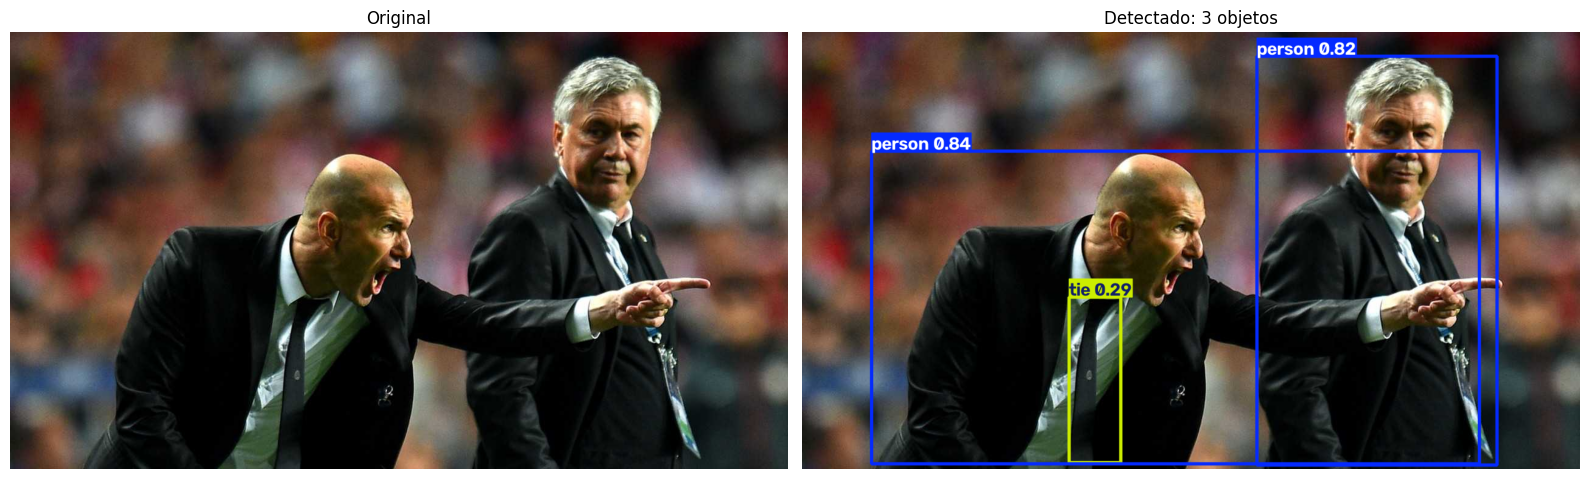

  person: 0.84
  person: 0.82
  tie: 0.29


In [6]:
# ============ CELDA 6: Probar con otra imagen ============
url2 = 'https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/zidane.jpg'
urllib.request.urlretrieve(url2, 'zidane.jpg')

results2 = model('zidane.jpg')
result2 = results2[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(Image.open('zidane.jpg'))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(result2.plot()[:, :, ::-1])
axes[1].set_title(f'Detectado: {len(result2.boxes)} objetos')
axes[1].axis('off')

plt.tight_layout()
plt.show()

for box in result2.boxes:
    print(f"  {result2.names[int(box.cls[0])]}: {float(box.conf[0]):.2f}")

### 6.3 Análisis de las detecciones

**Observa:**

1. **Clasificación + Localización simultánea:** Cada detección incluye clase + coordenadas.
2. **Confianza:** Valores entre 0 y 1 indican certeza del modelo.
3. **Múltiples objetos:** YOLO detecta personas, autobús, etc., sin problemas.
4. **Tiempo real:** La inferencia toma milisegundos en GPU.

**Comparación con LeNet-5:**

| Aspecto | LeNet-5 | YOLO |
|---------|---------|------|
| Tarea | Clasificación | Detección |
| Salida | 1 etiqueta | N cajas + etiquetas |
| Entrada | 28×28 | 448×448 (o más) |
| Velocidad | Instantánea | Tiempo real (~45 FPS) |

---

## 7. Transfer Learning con YOLO

### 7.1 Concepto

En lugar de entrenar desde cero, usamos un modelo preentrenado en COCO y lo **fine-tuneamos** en nuestro dataset específico [citation:5][citation:19].

### 7.2 Pasos para fine-tuning

```python
model = YOLO('yolov8n.pt')  # Modelo preentrenado
results = model.train(data='mi_dataset.yaml', epochs=10, imgsz=640)
```

### 7.3 ¿Por qué funciona?

- Las **capas iniciales** aprenden características genéricas (bordes, texturas).
- Las **capas finales** se adaptan a las clases específicas.
- Requiere **menos datos** y **menos épocas** que entrenar desde cero.

### 7.4 Ejemplo de dataset para fine-tuning

El formato YOLO para etiquetas:

```
# Formato: class_id x_center y_center width height (normalizado 0-1)
0 0.5 0.5 0.3 0.4
1 0.2 0.3 0.1 0.15
```

---

## 8. Resumen de la Parte 4

### Conceptos clave

| Concepto | Descripción |
|----------|-------------|
| **Grid $S\times S$** | Divide la imagen en celdas; cada una predice objetos |
| **Bounding boxes** | $B$ cajas por celda con $(x,y,w,h,\text{confianza})$ |
| **Confianza** | $P(\text{objeto}) \times \text{IoU}$ |
| **Tensor salida** | $S \times S \times (B \cdot 5 + C)$ |
| **Loss** | 5 componentes: localización + confianza + clasificación |
| **Transfer learning** | Usar modelo preentrenado y fine-tunear |

### Preguntas para reflexionar

1. ¿Por qué YOLO usa una cuadrícula en lugar de procesar la imagen completa?
2. ¿Por qué la función de pérdida usa $\sqrt{w}$ y $\sqrt{h}$ en lugar de $w$ y $h$ directamente?
3. ¿Cuándo conviene usar YOLO vs LeNet-5?
4. ¿Qué ventajas tiene el transfer learning frente a entrenar desde cero?

### Cierre de la clase

**Hemos recorrido:**

1. **Parte 1:** Fundamentos teóricos (convolución, filtros, stride, padding).
2. **Parte 2:** LeNet-5 en TensorFlow/Keras.
3. **Parte 3:** LeNet-5 en PyTorch.
4. **Parte 4:** YOLO y detección de objetos.

**Mensaje final:** La misma operación de convolución que clasifica dígitos (LeNet-5) también detecta objetos en imágenes complejas (YOLO). La diferencia está en la **arquitectura** y la **tarea de salida**.